# Intrinsic neural timescales

An intrinsic neural timescale (INT) is how long a region's signal stays correlated with itself —
short in sensory cortex, long in association cortex.

Estimating one takes two steps: turn a time series into an autocorrelation function, then reduce
that function to a single number. {mod}`snaplab_tools.timescales` does both. The second step is
where the decisions live, because an ACF is a *curve* and an INT is some scalar summary of it.

{mod}`snaplab_tools.signal` appears too, for filtering, because whether you filter before
estimating changes the answer.

This page is about estimating an INT with these tools, not about what an INT means. For the
broader picture — how timescales arise from circuit dynamics, what they are good for, and the
methodological arguments between the various estimators — see Zeraati et al. (2026).

:::{seealso}
Zeraati, R., Levina, A., Macke, J.H., & Gao, R. (2026). Neural timescales from a computational
perspective. *Nature Neuroscience*. <https://doi.org/10.1038/s41593-026-02343-8>
:::

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from snaplab_tools.datasets import make_timeseries
from snaplab_tools.signal import apply_frequency_filter
from snaplab_tools.timescales import (
    TIMESCALE_METHODS,
    compute_acf,
    compute_timescale,
    decay_time,
    zero_crossing,
)
from snaplab_tools.plotting.utils import set_plotting_params

set_plotting_params()

## Data

{func}`~snaplab_tools.datasets.make_timeseries` generates AR(1) series whose decay constant varies
across regions, mimicking the gradient of intrinsic timescales observed along the cortical
hierarchy.

The reason to work with simulated series here is that we have **the ground truth for the INTs!** In turn, every INT estimator
below can be checked against the timescale each region was actually built with, which is not
something you can do with real data.

In [2]:
data = make_timeseries(n_regions=50, n_timepoints=1200, tr=0.8, seed=0)

ts = data['ts']         # (n_regions, n_timepoints)
tau_true = data['tau']  # the timescale each region was built with, in seconds
tr = data['tr']

print(f'time series: {ts.shape}, TR = {tr}s ({ts.shape[1] * tr / 60:.0f} min)')
print(f'true timescales: {tau_true.min():.1f}s to {tau_true.max():.1f}s')

time series: (50, 1200), TR = 0.8s (16 min)
true timescales: 1.0s to 8.0s


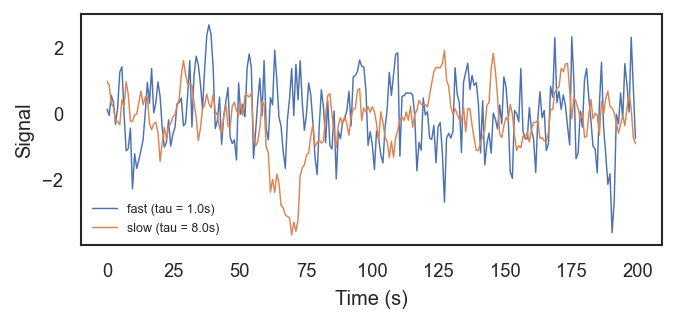

In [3]:
time = np.arange(ts.shape[1]) * tr

fig, ax = plt.subplots(figsize=(5, 2), dpi=150)
for region, label in [(0, f'fast (tau = {tau_true[0]:.1f}s)'),
                      (49, f'slow (tau = {tau_true[49]:.1f}s)')]:
    ax.plot(time[:250], ts[region, :250], lw=0.7, label=label)
ax.set_xlabel('Time (s)'); ax.set_ylabel('Signal')
ax.legend(fontsize=6, frameon=False)
plt.show()

The slow region visibly wanders over long time periods; the fast one is more jagged. That difference is what the
autocorrelation function quantifies.

## Filtering

{func}`~snaplab_tools.signal.apply_frequency_filter` applies a zero-phase Butterworth filter (via `filtfilt`).

Give it `lowpass`, `highpass`, or both for a bandpass. The canonical resting-state band is roughly
0.01–0.08 Hz.

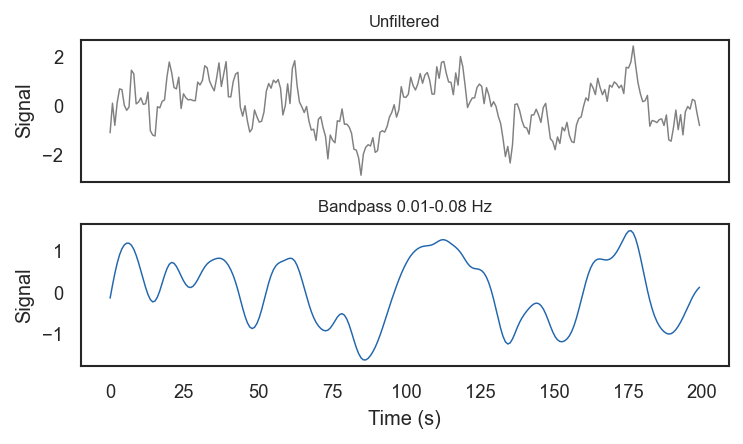

In [4]:
sampling_freq = 1 / tr
filtered = apply_frequency_filter(ts, sampling_freq, lowpass=0.08, highpass=0.01)

fig, axes = plt.subplots(2, 1, figsize=(5, 3), dpi=150, sharex=True)
axes[0].plot(time[:250], ts[25, :250], lw=0.7, color='gray')
axes[0].set_title('Unfiltered', fontsize=8); axes[0].set_ylabel('Signal')
axes[1].plot(time[:250], filtered[25, :250], lw=0.7, color='#2166AC')
axes[1].set_title('Bandpass 0.01-0.08 Hz', fontsize=8)
axes[1].set_xlabel('Time (s)'); axes[1].set_ylabel('Signal')
plt.tight_layout()
plt.show()

The filter removes both the high-frequency jitter and any slow drift, leaving the band where
resting-state fluctuations of interest live (we think.. this an open debate!).

:::{warning}
Filtering changes the autocorrelation — that is what a filter *is*. A low-pass filter makes every
region look slower, so a timescale computed after band-passing is a timescale of the filtered
signal, not of the neural process. The timescales below are computed on the
**unfiltered** series.
:::

## The autocorrelation function

{func}`~snaplab_tools.timescales.compute_acf` takes one series or a whole parcellation and returns
the autocorrelation at every lag, normalised so the curve starts at 1. `nlags` truncates it: a
timescale is determined by the first part of the curve, and keeping all 1,200 lags of a 16-minute
scan wastes memory on a tail that is mostly noise.

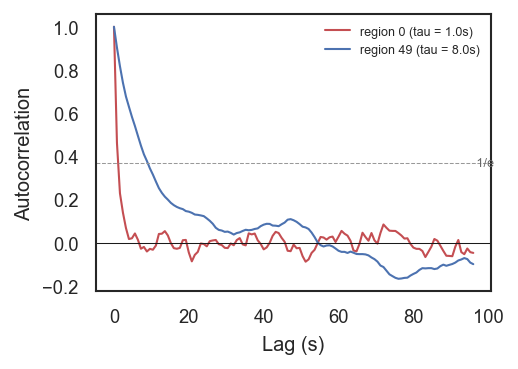

In [5]:
acf = compute_acf(ts, nlags=120)      # (50 regions, 121 lags)
lags = np.arange(acf.shape[1]) * tr

fig, ax = plt.subplots(figsize=(3.4, 2.4), dpi=150)
for region, colour in [(0, '#C44E52'), (49, '#4C72B0')]:
    ax.plot(lags, acf[region], lw=1,
            label=f'region {region} (tau = {tau_true[region]:.1f}s)', color=colour)
ax.axhline(0, color='k', lw=0.5)
ax.axhline(1 / np.e, color='0.6', lw=0.5, ls='--')
ax.text(lags[-1], 1 / np.e, ' 1/e', va='center', fontsize=6, color='0.4')
ax.set_xlabel('Lag (s)'); ax.set_ylabel('Autocorrelation')
ax.legend(fontsize=6, frameon=False)
plt.show()

Both curves decay, the slow region's more gradually. Everything that follows is a way of turning
one of those curves into one number.

## Many estimates of INTs

{data}`~snaplab_tools.timescales.TIMESCALE_METHODS` lists what is available, and
{func}`~snaplab_tools.timescales.compute_timescale` dispatches the options by name — so computing all of them
and comparing in a loop is easy.

Because we know the true tau of every region, we can score each estimator on how well it recovers tau using a correlation over regions.

In [6]:
estimates = {name: compute_timescale(acf, tr=tr, method=name) for name in TIMESCALE_METHODS}

print(f"{'method':20s} {'r(true tau)':>16s} {'valid':>8s}   range")
for name, values in estimates.items():
    ok = np.isfinite(values)
    r = np.corrcoef(tau_true[ok], values[ok])[0, 1]
    print(f'{name:20s} {r:16.2f} {f"{ok.sum()}/50":>8s}   '
          f'{np.nanmin(values):.2f} to {np.nanmax(values):.2f}')

method                    r(true tau)    valid   range
zero_crossing                    0.55    48/50   4.00 to 69.60
auc_zero_crossing                0.81    48/50   1.08 to 13.23
auc_half_crossing                0.94    50/50   0.00 to 4.12
decay_time                       0.95    50/50   1.60 to 9.60
decay_time_half                  0.94    50/50   0.80 to 6.40
lag_one                          0.90    50/50   0.46 to 0.91


A few non-exhaustive notes about the above!

Here, we see that **`decay_time` recovers the ground truth best (r = 0.95), and it is the only one on the same scale as
the true tau.** This is by design here due to the simulated data we use: these are AR(1) series, whose autocorrelation is
`exp(-lag / tau)`, and that curve passes 1/e exactly at `lag = tau`. Its estimates span 1.6–9.6 s
against a true 1.0–8.0 s because "first lag below the threshold" always rounds *up* to the lag
grid — at TR = 0.8 s that is up to 0.8 s of overestimate, and it shrinks with a shorter TR.

**`zero_crossing` is the weakest here (r = 0.55), with estimates from 4 to 70 s and two regions
returning NaN.** Again this happens by design, and worth understanding before using it: an exponential decay
never actually reaches zero, so for data like this the crossing is set by wherever sampling noise
first dips below the axis, not by tau. It is a good estimator when the ACF genuinely oscillates
through zero, and a poor one when it just decays.

**`lag_one` tracks tau well (r = 0.90) but it is not in seconds so its not always useful** — its values run 0.46 to 0.91 because
it is a correlation. It is comparable across regions within a dataset, but not across datasets
with different TRs.

**`auc_half_crossing` reports 0.00 s for one region.** A zero is not a fitting failure here: that
region's ACF is already below 0.5 at lag 1, so there is no area to integrate. Estimators that
integrate to a threshold need the threshold to be reachable.

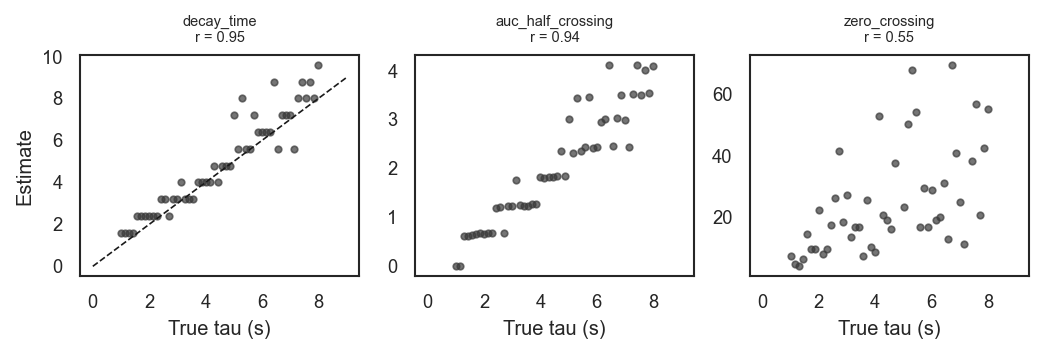

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(7, 2.4), dpi=150, sharex=True)
for ax, name in zip(axes, ['decay_time', 'auc_half_crossing', 'zero_crossing']):
    values = estimates[name]
    ok = np.isfinite(values)
    ax.scatter(tau_true[ok], values[ok], s=10, alpha=0.7, color='#3B3B3B')
    ax.set_title(f'{name}\nr = {np.corrcoef(tau_true[ok], values[ok])[0, 1]:.2f}', fontsize=7)
    ax.set_xlabel('True tau (s)')
axes[0].set_ylabel('Estimate')
# decay_time is the only one on the same scale as the truth, so only it gets an identity line.
axes[0].plot([0, 9], [0, 9], 'k--', lw=0.8)
plt.tight_layout(); plt.show()

`decay_time` sits on the identity line in visible steps — the steps are the lag grid, and they are
the resolution limit of any crossing-based estimator. `auc_half_crossing` is monotonic with the ground truth
but on its own scale, so it ranks regions correctly while not estimating tau. `zero_crossing` is
the scattered one, for the reason above.

Note, ranking regions and estimating a time constant are different jobs, and an estimator can be good at
the first while being useless for the second.

## Units: `tr` is not optional

Every estimator counts lags and multiplies by `tr`. Leave `tr` at its default of 1.0 and you will just get INTs in
lags — which is a perfectly good unit, but it is not seconds, and the difference is a factor of
your TR. {func}`~snaplab_tools.timescales.compute_timescale` says so rather than letting it pass:

In [8]:
import warnings

with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter('always')
    in_lags = compute_timescale(acf, method='decay_time')            # tr left at 1.0
    in_seconds = compute_timescale(acf, tr=tr, method='decay_time')  # tr = 0.8 s

print(caught[0].message)
print()
print(f'region 49 -> {in_lags[49]:.1f} lags = {in_seconds[49]:.1f} seconds at TR = {tr}s')

compute_timescale(method='decay_time') was called with tr=1.0, the default, so the result is in TRs rather than seconds -- multiplying a lag count by 1.0 leaves it a lag count. Pass your acquisition's TR (e.g. tr=0.72) for seconds, or verbose=False if your TR really is 1.0 s or lags are the unit you want.

region 49 -> 12.0 lags = 9.6 seconds at TR = 0.8s


Pass `verbose=False` to silence it once you have decided. This could be because your TR really is 1.0 s, or
because lags are the unit you want.

## How much data do you need?

Timescale estimates are noisy, and how noisy depends on scan length. Since the true values are
known here, we can measure that rather than guess at it.

In [9]:
# Averaged over five simulations: a single run is noisy enough that the shortest scans can look
# better than slightly longer ones by chance, which would be an artefact of one seed rather than
# a result.
for n_timepoints in (150, 300, 600, 1200):
    scores = []
    for seed in range(5): # repeated sims
        short = make_timeseries(n_regions=50, n_timepoints=n_timepoints, tr=0.8, seed=seed)
        est = decay_time(compute_acf(short['ts'], nlags=min(120, n_timepoints - 1)),
                         tr=short['tr'])
        ok = np.isfinite(est)
        scores.append(np.corrcoef(short['tau'][ok], est[ok])[0, 1])
    print(f'{n_timepoints:5d} volumes ({n_timepoints * 0.8 / 60:4.1f} min): '
          f'r = {np.mean(scores):.2f}  (range {min(scores):.2f}-{max(scores):.2f} over 5 sims)')

  150 volumes ( 2.0 min): r = 0.67  (range 0.64-0.72 over 5 sims)
  300 volumes ( 4.0 min): r = 0.75  (range 0.70-0.79 over 5 sims)
  600 volumes ( 8.0 min): r = 0.84  (range 0.79-0.88 over 5 sims)
 1200 volumes (16.0 min): r = 0.91  (range 0.87-0.95 over 5 sims)


Recovery degrades steadily as the scan shortens: r ≈ 0.91 at 16 minutes, 0.84 at 8, 0.75 at 4, and
0.67 at 2. Nothing fails loudly — every region still returns a number at every scan length. The
estimates simply get worse.

That matters most when the timescale map is an *input* to something else. Measurement noise
attenuates every correlation computed from it, so a weak brain-map correlation on a five-minute
scan may be telling you about your scan duration rather than about the brain. If you are comparing
groups or sessions, comparing timescale maps from scans of different lengths builds that
attenuation straight into the contrast.

## See also

- [Spatial null models](null_models.ipynb) — testing a timescale map against another brain map,
  with a null that respects spatial autocorrelation
- {func}`~snaplab_tools.timescales.compute_timescale` and
  {data}`~snaplab_tools.timescales.TIMESCALE_METHODS` — the estimator list, and dispatching by name
- {func}`~snaplab_tools.datasets.make_timeseries` — the generator behind this page, including its
  `tau_range`
- {func}`~snaplab_tools.signal.apply_frequency_filter` — the filter used above